# Criticality analyis

Criticality is another central concept in analysis of brain oscillations. In this tutorial will will introduce:

1. Detrended fluctuation analysis (DFA)
2. Functional excitation-inhibition index (fEI)
3. Bistability index (BiS). 
    - NOTE: TO BE ADDED AFTER GENEREATED SUITABLE BISTABLE SIGNAL
4. Phase-autocorrelation function (pACF). 
    - NOTE: TO BE ADDED INTO CROSSPY

## 1. Detrended Fluctuation Analysis (DFA)

We start by importing the needed libraries for the analysis.

In [1]:
import crosspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:
import scipy as sp
import pickle

import os

from tutorial_utils import load_example_data

In [3]:
data_broadband, data_labels, data_info = load_example_data(max_time=300)

In [4]:
data_filt = crosspy.preprocessing.signal.filter_data(data_broadband, sfreq=data_info['sfreq'], frequency=7.8, omega=5.0, n_jobs='cuda')
data_envelope = np.abs(data_filt)

In [5]:
samples_per_cycle = data_info['sfreq']/7.8

window_lengths = np.geomspace(int(10*samples_per_cycle), data_envelope.shape[-1]//4, 30)
dfa_res = crosspy.observables.criticality.lrtc.compute_dfa(data_envelope, window_lengths, method='fft')

We can now utilize the fluctuation function <span style="color:#85C1E9">fluct</span> provided by crosspy's <span style="color:#F9E79F">dfa</span> method, for determing self-similiarity for a <span style="color:#85C1E9">node_number</span> of interest.

We plot fluctuation function <span style="color:#85C1E9">fluct</span> as a function of our earlier generated <span style="color:#85C1E9">window_lengths</span> and set logarithmic axes. Additionally we add a trendline to the plot.

In [18]:
def plot_DFA_fluctuation(window_lengths, fluct, nodes_list=list(), ax=None):
    #selecting the row corresponding to the node_number of interest
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    
    for idx, node_number in enumerate(nodes_list):
        #plotting window_length and selected_fluct of interest
    
        ax.plot(window_lengths, fluct[node_number], marker='o', linestyle='', color=f'C{idx}', alpha=0.5)
        
        
        #linear regression of logarithmic values
        log_window_lengths = np.log10(window_lengths) #log10 of window_lengths
        log_selected_fluct = np.log10(fluct[node_number]) #log10 of fluctuation value of node of interest
        slope, intercept, _, _, _ = linregress(log_window_lengths, log_selected_fluct) #storing slope and intercept of line
        
        #calculating trendline and plotting it
        trendline_x = np.linspace(min(log_window_lengths), max(log_window_lengths), 100)
        trendline_y = slope * trendline_x + intercept
        ax.plot(10**trendline_x, 10**trendline_y, color=f'C{idx}', label=f'DFA={slope:.2f}') #converting from logarithmic scale to original scale and plotting
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    #adding title and axis labels
    ax.set_xlabel('Window Length (log scale)')
    ax.set_ylabel('Fluctuation (log scale)')

    #showing plot with specific gridlines, and legend
    ax.grid(True, which='both', ls='--', linewidth=0.5, axis='both', color='gray')
    ax.legend()

The fluctuation function <span style="color:#85C1E9">fluct</span> follows a power law if the time series is self-similar:
$$fluct(n) \propto n^\alpha$$

The exponent $\alpha$ informs on the nature of self-correlations within the time series:

- $\alpha = 0.5 \quad$ **white noise**

- $0.5 < \alpha < 1 \quad$ **correlated noise**

- $\alpha > 1 \quad$ **random walk**

- $\alpha = 1.5 \quad$ **brownian motion**

Let's call the above plotting method e.g. for the second node to study it further.

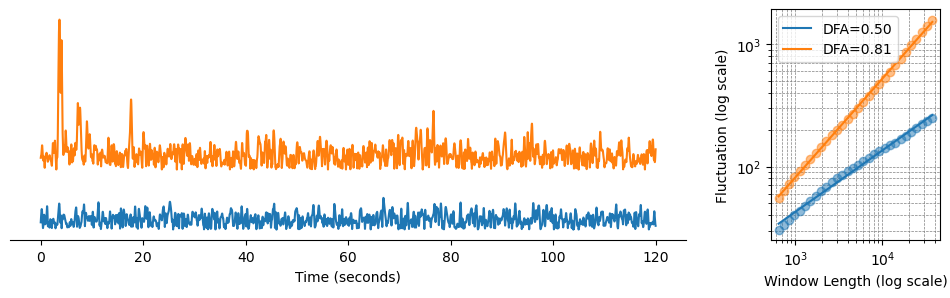

In [72]:
nodes_to_plot = np.abs((dfa_res.dfa_values[None] - np.array([0.5, 0.8])[:, None])).argmin(axis=-1)
vis_ts = np.arange(60000)/data_info['sfreq']

fig, axes = plt.subplots(figsize=(12,3), ncols=2,  gridspec_kw={'width_ratios': [4, 1]})

axes[0].plot(vis_ts, data_envelope[nodes_to_plot, :60000].T.get() + np.arange(2)[None]*5)

plot_DFA_fluctuation(window_lengths, dfa_res.fluctuation, nodes_to_plot, ax=axes[1])

axes[0].set_xlabel('Time (seconds)')
axes[0].set_yticks([])

for sp_name in ['top', 'left', 'right']:
    axes[0].spines[sp_name].set_visible(False)

In [ ]:
test_data_envelope = np.load(os.path.join('demo_files', 'bad_dfa_fits_data.npy'))

dfa_res_bad = crosspy.observables.criticality.lrtc.compute_dfa(test_data_envelope, window_lengths, method='fft')

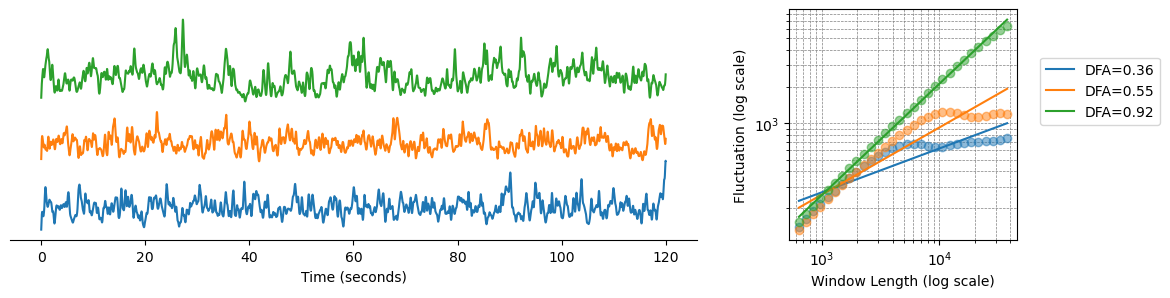

In [71]:
vis_ts = np.arange(60000)/data_info['sfreq']

fig, axes = plt.subplots(figsize=(13,3), ncols=2,  gridspec_kw={'width_ratios': [3, 1]})

axes[0].plot(vis_ts, test_data_envelope[:, :60000].T + np.arange(3)[None]*15)

plot_DFA_fluctuation(window_lengths, dfa_res_bad.fluctuation, [0,1,2], ax=axes[1])

axes[0].set_xlabel('Time (seconds)')
axes[0].set_yticks([])

axes[1].legend(loc=[1.1,0.5])

for sp_name in ['top', 'left', 'right']:
    axes[0].spines[sp_name].set_visible(False)